Analyze EMG vs head motion vs DLC motion data for each animal / session.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import platform
from pathlib import Path
from os import environ
if platform.system() == "Darwin": # Nat laptop
    sys.path.extend(['/Users/nkinsky/Documents/UM/GitHub/NeuroPy'])
    sys.path.extend(['/Users/nkinsky/Documents/UM/GitHub/Projects_sandbox'])
else:
    if environ["HOSTNAME"] == "lnx00004": # Nat Linux computer
        sys.path.extend(['/data/GitHub/NeuroPy'])
        sys.path.extend(['/data/GitHub/Projects_sandbox'])
    
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import scipy.signal as sg
import matplotlib.pyplot as plt
from neuropy.utils.mathutil import min_max_scaler
from scipy.ndimage import gaussian_filter1d, gaussian_filter
from copy import deepcopy
from tqdm import tqdm

from neuropy import plotting
from neuropy.analyses.placefields import Pf1D, Pf1Dsplit
from neuropy.analyses.oscillations import detect_theta_epochs
from neuropy.core.position import Position
from neuropy.core.epoch import Epoch
from neuropy.core.session import ProcessData
from neuropy.plotting.ratemaps import plot_ratemap
from neuropy.plotting.figure import Fig
from neuropy.utils.misc import flatten
from neuropy.io import BinarysignalIO
from neuropy.io.miniscopeio import MiniscopeIO
from neuropy.io.sleepscoremasterio import SleepScoreIO
from neuropy.io.dlcio import DLC
from neuropy.utils.mathutil import min_max_scaler, min_max_external_scaler, quantile_scaler

from Psilocybin.subjects import get_psi_dir

# These are crucial parameters - otherwise all text gets output with each letter in a word or heading as a separate unit
# instead of a text box
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

# Specify Arial as font type - also crucial
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'


In [87]:
# Specify desired place to plot here.
if platform.system() == "Darwin": # Nat laptop
    plot_dir = Path("/Users/nkinsky/University of Michigan Dropbox/Nathaniel Kinsky/Manuscripts/Psilocybin/plots")
else:
    if environ["HOSTNAME"] == "lnx00004": # Nat Linux computer
        plot_dir = Path("/home/nkinsky/Dropbox (University of Michigan)/Manuscripts/Psilocybin/plots")

## Specify plotting parameters

In [3]:
animals = ["Finn", "Rey", "Rose", "Finn2"]
rasterize_scatter = True # This is crucial, default (False) will produce unwieldy plots

/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


# Run through one animal session to check

## Load in animal data

In [4]:
animal = "Finn2"
session = "Psilocybin"

# Load in session
sess = ProcessData(get_psi_dir(animal, session))

# Load in Miniscope data and process head angular position
sess.miniscope = MiniscopeIO(sess.basepath)
sess.miniscope.load_all_orientation()
sess.miniscope.load_aligned_timestamps()
sess.headpos = sess.miniscope.to_head_ang_pos(times="aligned")
sess.ms_times_aligned = pd.read_csv(sorted(sess.basepath.glob("*.ms_times_aligned.csv"))[0], index_col=0)

# Load in DeepLabCut position data
sess.dlc = DLC(sess.basepath)
sess.dlc.get_timestamps()
sess.dlc.load_opti_aligned_timestamps()
sess.dlc.smooth_pos()
sess.dlc.get_all_speed()
sess.dlc_times_aligned = pd.read_csv(sorted(sess.basepath.glob("*.opti_times_aligned.csv"))[0], index_col=0)

# Load in EMG data from sleepscoremaster
sess.sio = SleepScoreIO(sess.basepath)
sess.emg = sess.sio.read_emg()

# Load in injection data
sess.injection = Epoch(epochs=None, file=sorted(sess.basepath.glob("*.injection.npy"))[0])
inj_time = sess.injection["POST"].starts[0]


including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/pre/Finn2/gobears/2023_05_25/11_30_40
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/pre/Finn2/gobears/2023_05_25/11_31_12
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/pre/Finn2/gobears/2023_05_25/11_35_03
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_08_16
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_08_32
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_29_42
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_41_05
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_41_32
including folder /data3/Psilocybin/Re

### Do quick plot of pEMG, DLC derived motion, and miniscope (MS) derived head angular speed across entire session

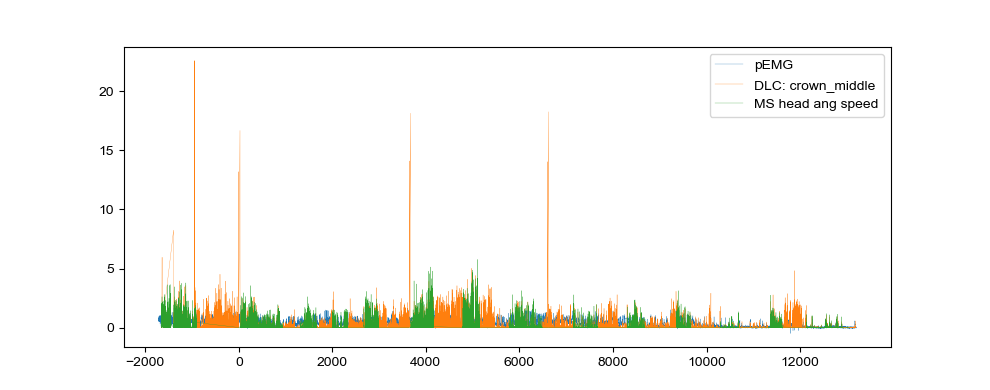

In [5]:
%matplotlib widget
bodypart = "crown_middle"
fig, ax = plt.subplots(figsize=[9.9, 3.9])
ax.plot(sess.emg.timestamps - inj_time, quantile_scaler(sess.emg.pEMG.values), linewidth=0.2, label="pEMG")
ax.plot(sess.dlc.times_aligned.eeg_aligned_times - inj_time, 
        quantile_scaler(sess.dlc.speed[bodypart].values), label=f"DLC: {bodypart}", linewidth=0.2)
ax.plot(sess.ms_times_aligned["Timestamps"] - inj_time, quantile_scaler(sess.headpos.speed), label="MS head ang speed", linewidth=0.2)
ax.legend()

## Now quantify each metric during PRE, and in 15 minute blocks post injection


In [6]:
# First align all timestamps to injection time
sess.emg["inj_aligned_ts"] = sess.emg['timestamps'] - inj_time
sess.dlc.times_aligned["inj_aligned_ts"] = sess.dlc.times_aligned.eeg_aligned_times - inj_time
sess.ms_times_aligned["inj_aligned_ts"] = sess.ms_times_aligned["Timestamps"] - inj_time

In [7]:
def mean_by_block(t, metric, block_start, block_stop):
    assert len(t) == len(metric)
    block_bool = (t >= block_start) & (t < block_stop)
    return np.nanmean(metric[block_bool]), np.nanstd(metric[block_bool])
mean_by_block(sess.emg.inj_aligned_ts, sess.emg.pEMG, -900, 0)

(0.3941726675703976, 0.15353252962167008)

/tmp/ipykernel_113943/2453554655.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(metric[block_bool]), np.nanstd(metric[block_bool])
/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


<Axes: xlabel='Block', ylabel='value'>

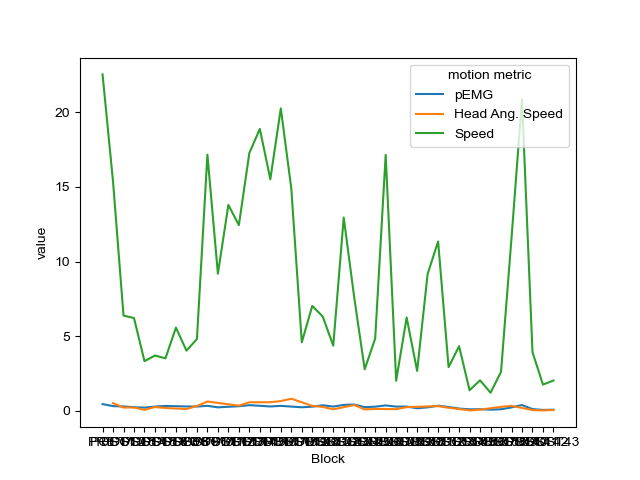

In [9]:
block_size_min = 5
block_times = np.arange(-block_size_min * 60, sess.emg.inj_aligned_ts.max(), block_size_min * 60)
pEMG, ang_speed, speed, block_names = [], [], [], []
for idb, (t_block_start, t_block_stop) in enumerate(zip(block_times[:-1], block_times[1:])):
    pEMG.append(mean_by_block(sess.emg.inj_aligned_ts, sess.emg.pEMG, t_block_start, t_block_stop)[0])
    ang_speed.append(mean_by_block(sess.ms_times_aligned.inj_aligned_ts, sess.headpos.speed, t_block_start, t_block_stop)[0])
    speed.append(mean_by_block(sess.dlc.times_aligned.inj_aligned_ts.values, sess.dlc.speed[bodypart], t_block_start, t_block_stop)[0])
    if idb == 0:
        block_names.append("PRE")
    else:
        block_names.append(f"POST{idb}")

motion_block_df = pd.DataFrame({"Block": block_names, "pEMG": pEMG, "Head Ang. Speed": ang_speed, "Speed": speed})

_, ax = plt.subplots()
motion_block_df_rs = motion_block_df.melt(id_vars="Block", value_vars=["pEMG", "Head Ang. Speed", "Speed"], var_name="motion metric")
sns.lineplot(data=motion_block_df_rs, x="Block", y="value", hue="motion metric", ax=ax)

# Now run through all animals together

In [21]:
group_motion_df = []
group_motion_all_df = []
errors = []
for animal in animals:
    for session in ["Saline1", "Psilocybin", "Saline2"]:
        # Load in session
        sess = ProcessData(get_psi_dir(animal, session))
        
        # Load in Miniscope data and process head angular position
        sess.miniscope = MiniscopeIO(sess.basepath)
        sess.miniscope.load_all_orientation()
        sess.miniscope.load_aligned_timestamps()
        sess.headpos = sess.miniscope.to_head_ang_pos(times="aligned")
        sess.ms_times_aligned = pd.read_csv(sorted(sess.basepath.glob("*.ms_times_aligned.csv"))[0], index_col=0)
        
        # Load in DeepLabCut position data
        sess.dlc = DLC(sess.basepath)
        sess.dlc.get_timestamps()
        sess.dlc.load_opti_aligned_timestamps()
        sess.dlc.smooth_pos()
        sess.dlc.get_all_speed()
        sess.dlc_times_aligned = pd.read_csv(sorted(sess.basepath.glob("*.opti_times_aligned.csv"))[0], index_col=0)
        
        # Load in EMG data from sleepscoremaster
        sess.sio = SleepScoreIO(sess.basepath)
        sess.emg = sess.sio.read_emg()
        
        # Load in injection data
        sess.injection = Epoch(epochs=None, file=sorted(sess.basepath.glob("*.injection.npy"))[0])
        inj_time = sess.injection["POST"].starts[0]

        # Align all timestamps to injection time
        sess.emg["inj_aligned_ts"] = sess.emg['timestamps'] - inj_time
        sess.dlc.times_aligned["inj_aligned_ts"] = sess.dlc.times_aligned.eeg_aligned_times - inj_time
        sess.ms_times_aligned["inj_aligned_ts"] = sess.ms_times_aligned["Timestamps"] - inj_time

        # Now get mean by block
        block_times = np.arange(-block_size_min * 60, sess.emg.inj_aligned_ts.max(), block_size_min * 60)
        pEMG, ang_speed, speed, block_names = [], [], [], []
        for idb, (t_block_start, t_block_stop) in enumerate(zip(block_times[:-1], block_times[1:])):
            pEMG.append(mean_by_block(sess.emg.inj_aligned_ts, sess.emg.pEMG, t_block_start, t_block_stop))
            ang_speed.append(mean_by_block(sess.ms_times_aligned.inj_aligned_ts, sess.headpos.speed, t_block_start, t_block_stop))
            speed.append(mean_by_block(sess.dlc.times_aligned.inj_aligned_ts.values, sess.dlc.speed[bodypart], t_block_start, t_block_stop))
            if idb == 0:
                block_names.append("PRE")
            else:
                block_names.append(f"POST{idb}")

        # Aggregate all data into one DataFrame without averaging
        for t_use, met_use, name_use in zip([sess.emg.inj_aligned_ts, sess.ms_times_aligned.inj_aligned_ts, sess.dlc.times_aligned.inj_aligned_ts.values],
                                    [sess.emg.pEMG, sess.headpos.speed, sess.dlc.speed[bodypart]],
                                    ["pEMG", "Head Ang Speed (rad/s)", f"Speed {bodypart}"]):
            group_motion_all_df.append(pd.DataFrame({"Animal": animal, "Session": session, "Time (s)": t_use, 
                                                     "Value": met_use, "Metric": name_use}))
        
        pEMG, ang_speed, speed = np.array(pEMG), np.array(ang_speed), np.array(speed)
        motion_block_df = pd.DataFrame({"Animal": animal, "Session": session, 
                                        "Block": block_names, "pEMG": pEMG[:, 0], "Head Ang. Speed": ang_speed[:, 0], "Speed": speed[:, 0],
                                        "pEMG std": pEMG[:, 1], "Head Ang. Speed std": ang_speed[:, 1], "Speed std": speed[:, 1]})
        group_motion_df.append(motion_block_df)

group_motion_df = pd.concat(group_motion_df, axis=0, ignore_index=True)
group_motion_all_df = pd.concat(group_motion_all_df, axis=0, ignore_index=True)

including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Finn/gobears/2022_02_15/12_59_35
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Finn/gobears/2022_02_15/13_01_00
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Finn/gobears/2022_02_15/13_08_51
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Finn/gobears/2022_02_15/13_21_11
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Finn/gobears/2022_02_15/13_24_29
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Finn/gobears/2022_02_15/13_39_48
Using tracking file #0: /data3/Psilocybin/Recording_Rats/Finn/2022_02_15_saline1/Take 2022-02-15 01.00.59 PM-Camera 4 (#410110)DLC_resnet50_Psilocybin_DLCFeb13shuffle1_500000.h5
No Optitrack csv file found at Take 2022-02-15 01.00.59 PM-Camera 4 (#410110)DLC_resnet50_Psilocybin_DLCFeb13shuffle1_500000.
Inferring start time from file name. SECOND PRECISION 

/tmp/ipykernel_113943/2453554655.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(metric[block_bool]), np.nanstd(metric[block_bool])
/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/1_baseline/Finn/gobears/2022_02_17/10_33_54
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/2_psilocybin/Finn/gobears/2022_02_17/10_45_12
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/2_psilocybin/Finn/gobears/2022_02_17/11_16_16
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/2_psilocybin/Finn/gobears/2022_02_17/11_31_25
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/2_psilocybin/Finn/gobears/2022_02_17/11_44_46
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/2_psilocybin/Finn/gobears/2022_02_17/11_47_30
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/2_psilocybin/Finn/gobears/2022_02_17/11_57_46
including folder /data3/Psilocybin/Recording_Rats/Finn/2022_02_17_psilocybin/2_psilocybin/Finn/gobears/2022_02_17/12_08_01
including folder /

/tmp/ipykernel_113943/2453554655.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(metric[block_bool]), np.nanstd(metric[block_bool])
/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


Using tracking file #0: /data3/Psilocybin/Recording_Rats/Rey/2022_06_01_saline1/Take 2022-06-01 12.29.25 PM-Camera 3 (#410110)DLC_resnet50_Psilocybin_DLCFeb13shuffle1_500000.h5
No Optitrack csv file found at Take 2022-06-01 12.29.25 PM-Camera 3 (#410110)DLC_resnet50_Psilocybin_DLCFeb13shuffle1_500000.
Inferring start time from file name. SECOND PRECISION IN START TIME!!!
2022-06-01 12:29:25
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
get_speed not yet tested for optitrack data, use with caution
including folder /data3/Psilocybin/Recording_Rat

...

/tmp/ipykernel_113943/2453554655.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(metric[block_bool]), np.nanstd(metric[block_bool])
/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/pre/Finn2/gobears/2023_05_25/11_30_40
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/pre/Finn2/gobears/2023_05_25/11_31_12
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/pre/Finn2/gobears/2023_05_25/11_35_03
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_08_16
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_08_32
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_29_42
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_41_05
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_25_psilocybin/psilocybin/Finn2/gobears/2023_05_25/12_41_32
including folder /data3/Psilocybin/Re

/tmp/ipykernel_113943/2453554655.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(metric[block_bool]), np.nanstd(metric[block_bool])
/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/pre/Finn2/gobears/2023_05_26/11_44_01
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/pre/Finn2/gobears/2023_05_26/11_46_17
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/saline2/Finn2/gobears/2023_05_26/12_05_11
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/saline2/Finn2/gobears/2023_05_26/12_31_22
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/saline2/Finn2/gobears/2023_05_26/12_48_55
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/saline2/Finn2/gobears/2023_05_26/13_01_47
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/saline2/Finn2/gobears/2023_05_26/13_20_03
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_saline2/saline2/Finn2/gobears/2023_05_26/13_20_57
including folder /data3/Psilocybin/Recording_Rats/Finn2/2023_05_26_salin

/tmp/ipykernel_113943/2453554655.py:4: RuntimeWarning: Mean of empty slice
  return np.nanmean(metric[block_bool]), np.nanstd(metric[block_bool])
/home/nkinsky/miniforge3/envs/NeuroPy/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [ ]:
from copy import deepcopy
df_copy = deepcopy(group_motion_all_df)
df_copy

In [ ]:
# Use this before running the cell below if you get an error
group_motion_all_df.pop("Block")

In [22]:
block_size_min = 5
min_block = np.floor(group_motion_all_df["Time (s)"].min() / (block_size_min * 60)).astype(int)
max_block = np.ceil(group_motion_all_df["Time (s)"].max() / (block_size_min * 60)).astype(int)
blocks = np.arange(min_block, max_block + 1)
block_times = blocks * 60
for idb, (t_block_start, t_block_stop) in enumerate(zip(block_times[:-1], block_times[1:])):
    t = group_motion_all_df["Time (s)"]
    block_bool = (t >= t_block_start) & (t < t_block_stop)
    group_motion_all_df.loc[block_bool, "Block"] = idb
group_motion_all_df["Block"] = pd.Categorical(group_motion_all_df["Block"], 
                                              np.arange(np.nanmax(group_motion_all_df.Block.unique())))

### Plot motion across all animals over time
Multiple data points per animal in each time block

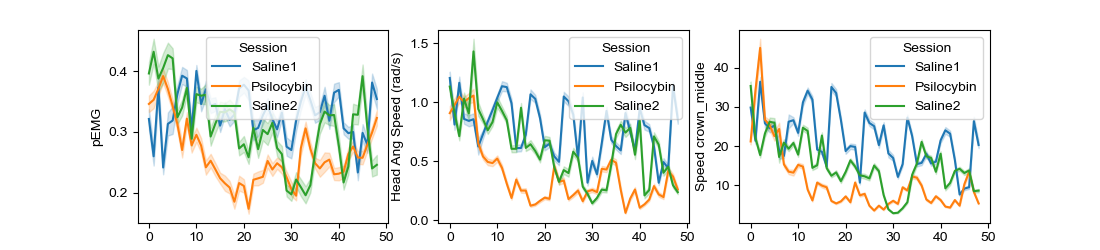

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(11, 2.5))

group_motion_good_df = group_motion_all_df[~np.isnan(group_motion_all_df.Block.astype(float))]
for a, metric in zip(ax, ["pEMG", "Head Ang Speed (rad/s)", f"Speed {bodypart}"]):
    metric_df = group_motion_good_df[group_motion_good_df["Metric"] == metric]
    sns.lineplot(data=metric_df, x="Block", y="Value", hue="Session", ax=a)
    a.set_ylabel(metric)

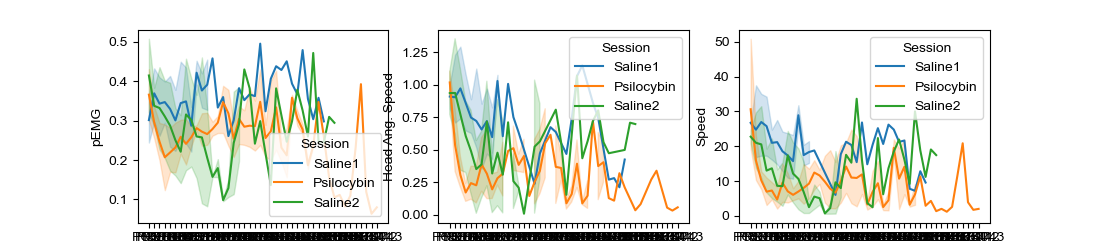

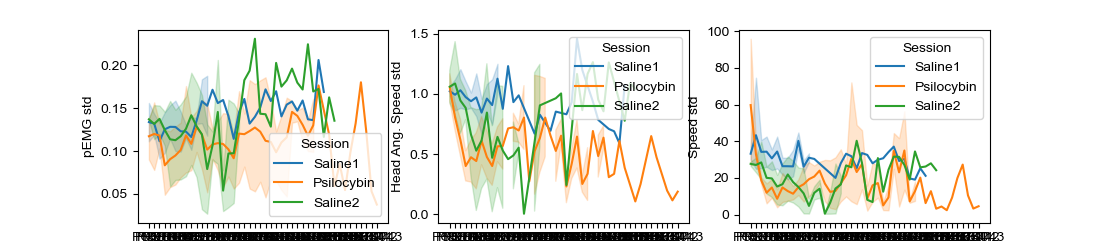

In [26]:
_, ax = plt.subplots(1, 3, figsize=(11, 2.5))
group_motion_df_rs = group_motion_df.melt(id_vars=["Block", "Animal", "Session"], value_vars=["pEMG", "Head Ang. Speed", "Speed"], var_name="motion metric")
for a, metric in zip(ax, ["pEMG", "Head Ang. Speed", "Speed"]):
    metric_df = group_motion_df_rs[group_motion_df_rs["motion metric"] == metric]
    sns.lineplot(data=metric_df, x="Block", y="value", hue="Session", ax=a)
    a.set_ylabel(metric)

_, ax = plt.subplots(1, 3, figsize=(11, 2.5))
group_motion_df_rs = group_motion_df.melt(id_vars=["Block", "Animal", "Session"], value_vars=["pEMG std", "Head Ang. Speed std", "Speed std"], var_name="motion metric")
for a, metric in zip(ax, ["pEMG std", "Head Ang. Speed std", "Speed std"]):
    metric_df = group_motion_df_rs[group_motion_df_rs["motion metric"] == metric]
    sns.lineplot(data=metric_df, x="Block", y="value", hue="Session", ax=a)
    a.set_ylabel(metric)

### Plot histograms and ecdfs in bins for motion
data points = `block_size` bins (in minutes) average of each metric combined across all animals

Define function for below

In [78]:
import matplotlib

def set_linestyles(ax):
    """Sets linestyles to differentiate between conditions for plots below"""
    line_bool = [isinstance(child, matplotlib.lines.Line2D) for child in ax[1].get_children()]
    hlines = np.array(ax[1].get_children())[line_bool]
    hlines[0].set_linestyle('--')
    hlines[0].set_label("Saline2")
    hlines[2].set_linestyle('--')
    hlines[2].set_label('Saline1')

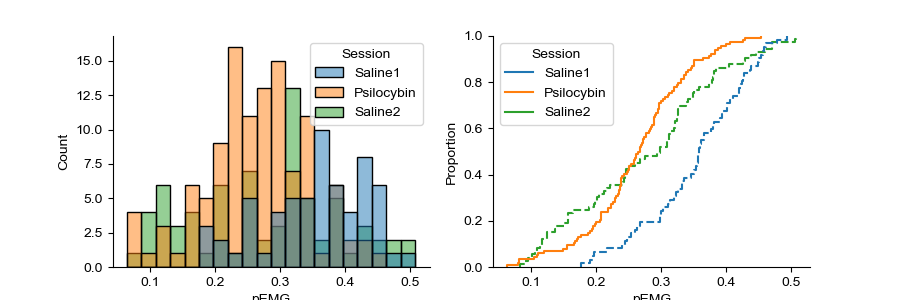

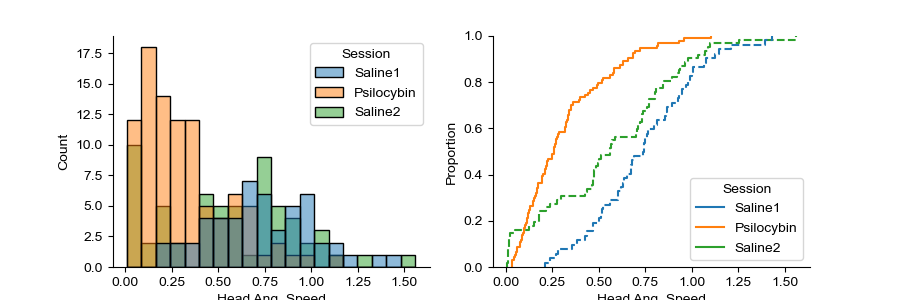

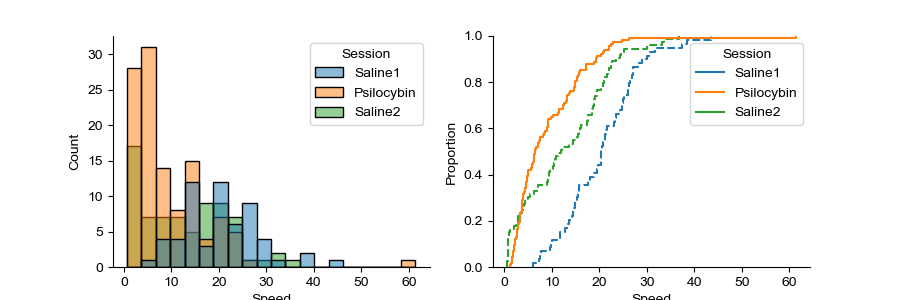

In [88]:
metrics_plot=["pEMG", "Head Ang. Speed", "Speed"]
group_motion_df_rs = group_motion_df.melt(id_vars=["Block", "Animal", "Session"], value_vars=metrics_plot, var_name="motion metric")

for metric in metrics_plot:
    fig, ax = plt.subplots(1, 2, figsize=(9, 3))
    sns.histplot(data=group_motion_df_rs[group_motion_df_rs["motion metric"] == metric], x="value", hue="Session", bins=20, ax=ax[0])
    ax[0].set_xlabel(metric)
    
    sns.ecdfplot(data=group_motion_df_rs[group_motion_df_rs["motion metric"] == metric], x="value", hue="Session", ax=ax[1])
    ax[1].set_xlabel(metric)
    set_linestyles(ax)
    sns.despine(fig=fig)

    fig.savefig(plot_dir / f'{"_".join(metric.replace(".", "").split(" "))}_histograms.pdf')

In [75]:


def set_linestyles(ax):
    """Sets linestyles to differentiate between conditions"""
    line_bool = [isinstance(child, matplotlib.lines.Line2D) for child in ax[1].get_children()]
    hlines = np.array(ax[1].get_children())[line_bool]
    hlines[0].set_linestyle('--')
    hlines[0].set_label("Saline2")
    hlines[2].set_linestyle('--')
    hlines[2].set_label('Saline1')